# scorecardpipeline 自动模型报告

本 notebook 演示如何使用 `scorecardpipeline` 快速构建评分卡模型，并使用 `auto_model_report` 自动生成模型评估报告。

## 功能特点

- 端到端评分卡建模（Pipeline 风格）
- 自动生成多 Sheet 结构 Excel 报告
- 包含 KS/AUC/PSI 等核心指标
- 逐特征分箱分析与可视化
- 评分卡参数与刻度配置

### 导入依赖

In [1]:
import sys
sys.path.append("../")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import scorecardpipeline as sp

print(f"scorecardpipeline 版本: {sp.__version__}")
sp

scorecardpipeline 版本: 0.1.39


<module 'scorecardpipeline' from 'C:\\Users\\18306\\Documents\\GitHub\\scorecardpipeline\\examples\\..\\scorecardpipeline\\__init__.py'>

### 加载数据

使用 scorecardpipeline 内置的 German Credit 数据集

In [3]:
# 加载数据
# 注意：原始标签列为 'creditability'，需要映射为 0/1
target = 'creditability'
data = sp.germancredit()
data[target] = data[target].map({'good': 0, 'bad': 1})

print(f"数据集大小: {data.shape}")
print(f"目标分布:\n{data[target].value_counts()}")

数据集大小: (1000, 21)
目标分布:
creditability
0    700
1    300
Name: count, dtype: int64


In [4]:
# 划分训练集和测试集
train, test = train_test_split(data, test_size=0.3, random_state=42)
print(f"训练集样本数: {len(train)}, 测试集样本数: {len(test)}")
print(f"训练集坏样本率: {train[target].mean():.2%}")
print(f"测试集坏样本率: {test[target].mean():.2%}")

训练集样本数: 700, 测试集样本数: 300
训练集坏样本率: 29.86%
测试集坏样本率: 30.33%


### 构建 Pipeline

使用 scorecardpipeline 的 Pipeline 构建端到端评分卡建模流程

In [5]:
# 构建 Pipeline
pipeline = sp.Pipeline([
    ('preprocessing_select', sp.FeatureSelection(target=target, engine='scorecardpy')),
    ('combiner', sp.Combiner(target=target, min_bin_size=0.2)),
    ('transform', sp.WOETransformer(target=target)),
    ('processing_select', sp.FeatureSelection(target=target, engine='toad')),
    ('stepwise', sp.StepwiseSelection(target=target)),
    ('logistic', sp.ITLubberLogisticRegression(target=target)),
])

In [6]:
# 训练 Pipeline
# 注意：需要传入完整数据（含目标列），Pipeline 会自动处理目标列
pipeline.fit(train)

[INFO] filtering variables ...


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing_select', ...), ('combiner', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,target,'creditability'
,empty,0.95
,iv,0.02
,corr,0.7
,exclude,None
,return_drop,True
,identical,0.95


### 构建逻辑回归模型

In [7]:
# 逻辑回归模型
logistic = pipeline['logistic']

# 查看入模特征
print(f"入模特征: {list(logistic.feature_names_in_)}")

入模特征: ['credit_amount', 'purpose', 'savings_account_and_bonds', 'credit_history', 'property', 'status_of_existing_checking_account', 'age_in_years', 'housing']


In [8]:
# 查看模型摘要
logistic.summary()

,Coef.,Std.Err,z,P>|z|,[ 0.025,0.975 ],VIF
const,-0.853023,0.095860,-8.898648,5.653082e-19,-1.040908,-0.665138,1.050301
credit_amount,0.866222,0.219050,3.954454,7.670949e-05,0.436885,1.295559,1.041104
purpose,0.906010,0.218257,4.151121,3.308515e-05,0.478227,1.333794,1.038664
savings_account_and_bonds,0.681405,0.263870,2.582355,9.812857e-03,0.164221,1.198590,1.059537
credit_history,0.745732,0.202456,3.683434,2.301132e-04,0.348919,1.142545,1.078023
property,0.706635,0.308270,2.292261,2.189058e-02,0.102426,1.310843,1.034041
status_of_existing_checking_account,0.806588,0.128079,6.297599,3.022905e-10,0.555554,1.057623,1.107430
age_in_years,0.822212,0.294219,2.794554,5.197138e-03,0.245542,1.398882,1.071333
housing,0.686183,0.288859,2.375497,1.752533e-02,0.120020,1.252347,1.043465


### 构建评分卡

In [9]:
# 构建评分卡，使用 pipeline 参数
scorecard = sp.ScoreCard(target=target, pipeline=pipeline)

# 在 WOE 转换后的数据上训练评分卡
scorecard.fit(pipeline[:-1].transform(train))

,target,'creditability'
,pdo,60
,rate,2
,base_odds,35
,base_score,750
,combiner,<toad.transfo...002C34CD49310>
,transer,<toad.transfo...002C34D407B90>
,pretrain_lr,ITLubberLogis...reditability')
,pipeline,Pipeline(step...itability'))])
,target,'creditability'
,empty,0.95


In [10]:
# 定义特征含义映射（用于报告展示）
feature_map = {
    'status_of_existing_checking_account': '支票账户状态',
    'credit_history': '信用历史',
    'purpose': '贷款目的',
    'credit_amount': '贷款金额',
    'savings_account_and_bonds': '储蓄账户',
    'present_employment_since': '就业时长',
    'housing': '住房情况',
    'property': '财产情况',
    'age_in_years': '年龄',
}

# 查看评分卡分值表
scorecard.scorecard_points(feature_map=feature_map)

,变量名称,变量含义,变量分箱,对应分数
0,credit_amount,贷款金额,"[负无穷 , 1388)",54.9830
1,credit_amount,贷款金额,"[1388 , 3914)",99.1454
2,credit_amount,贷款金额,"[3914 , 正无穷)",23.4144
3,purpose,贷款目的,"radio/television,furniture/equipment,car (used...",95.1703
4,purpose,贷款目的,"domestic appliances,education,business,others,...",26.5729
5,savings_account_and_bonds,储蓄账户,"500 <= ... < 1000 DM,... >= 1000 DM,unknown/ n...",101.6595
6,savings_account_and_bonds,储蓄账户,"... < 100 DM,100 <= ... < 500 DM",51.2556
7,credit_history,信用历史,critical account/ other credits existing (not ...,120.5116
8,credit_history,信用历史,"no credits taken/ all credits paid back duly,d...",45.9673
9,property,财产情况,real estate,97.8419


### 模型预测与评估

In [11]:
# 在测试集上预测评分
test_score = scorecard.predict(test)
print(f"测试集评分范围: [{test_score.min():.2f}, {test_score.max():.2f}]")
print(f"测试集评分均值: {test_score.mean():.2f}")

测试集评分范围: [290.29, 772.76]
测试集评分均值: 539.04


In [12]:
# 计算 KS 和 AUC
y_test = test[target]
test_proba = scorecard.predict_proba(test)[:, 1]

test_ks = sp.KS(test_proba, y_test)
test_auc = sp.AUC(test_proba, y_test)

print(f"测试集 KS: {test_ks:.4f}")
print(f"测试集 AUC: {test_auc:.4f}")

测试集 KS: 0.4721
测试集 AUC: 0.7631


### 自动生成模型报告

使用 `auto_model_report` 一键生成多 Sheet 结构的 Excel 模型评估报告

In [22]:
# 生成模型报告
# 需要传入包含目标列的数据集

sp.init_font_for_excel()

report = sp.auto_model_report(
    model=scorecard,
    datasets={'训练集': train.copy(), '测试集': test.copy(), '跨时间验证集': test.copy(), '样本外数据集': train.copy(), },
    target=target,
    excel_path='model_report/model_report.xlsx',
    n_bins=10,
    bin_method='quantile',
    with_plots=True,
    model_name='CreditScoreCard',
    project_desc='德国信贷评分卡模型',
    feature_map=feature_map,
    data_source='German Credit Dataset',
    amount_col='credit_amount',
    verbose=True,
)

模型评估快速报告

【模型性能指标】
 统计项    训练集      测试集   跨时间验证集   样本外数据集
  KS 0.4755   0.4721   0.4721   0.4755
 AUC 0.7980   0.7631   0.7631   0.7980
 样本数    700 300.0000 300.0000 700.0000
坏样本率 0.2986   0.3033   0.3033   0.2986
 PSI      \   0.3878   0.3878   0.0000

【Top 10 特征重要性】
                                     特征重要性
purpose                             0.1456
credit_amount                       0.1392
age_in_years                        0.1322
status_of_existing_checking_account 0.1297
credit_history                      0.1199
property                            0.1136
housing                             0.1103
savings_account_and_bonds           0.1095

【训练集评分分箱效果】
                   分箱    样本总数    好样本数   坏样本数   样本占比  好样本占比  坏样本占比   坏样本率  LIFT值  累积LIFT值    坏账改善  累积坏账改善  分档KS值
     [负无穷 , 393.9398)  405779  117347 288432 0.1702 0.0772 0.3332 0.7108 1.9581   1.9581  0.1964  0.1964 0.2559
[393.9398 , 435.7852)  315270  141095 174175 0.1322 0.0929 0.2012 0.5525 1.5219   1.7674  0.0795  0.3326 0.

In [14]:
# 查看报告文件
import os
if os.path.exists('model_report/model_report.xlsx'):
    print("\n报告文件已生成: model_report/model_report.xlsx")
    print(f"文件大小: {os.path.getsize('model_report/model_report.xlsx') / 1024:.2f} KB")

    # 查看生成的图表目录
    assets_dir = 'model_report_assets'
    if os.path.exists(assets_dir):
        print(f"\n图表目录: {assets_dir}")
        for f in os.listdir(assets_dir):
            print(f"  - {f}")


报告文件已生成: model_report/model_report.xlsx
文件大小: 7373.84 KB

图表目录: model_report_assets
  - bin_age_in_years_test.png
  - bin_age_in_years_train.png
  - bin_credit_amount_test.png
  - bin_credit_amount_train.png
  - bin_credit_history_test.png
  - bin_credit_history_train.png
  - bin_housing_test.png
  - bin_housing_train.png
  - bin_property_test.png
  - bin_property_train.png
  - bin_purpose_test.png
  - bin_purpose_train.png
  - bin_savings_account_and_bonds_test.png
  - bin_savings_account_and_bonds_train.png
  - bin_status_of_existing_checking_account_test.png
  - bin_status_of_existing_checking_account_train.png
  - bin_test.png
  - bin_train.png
  - ks_test.png
  - ks_train.png
  - score_psi_test.png


### 使用 QuickModelReport 类

直接使用 `QuickModelReport` 类进行更精细的控制

In [15]:
# 直接使用 QuickModelReport
report = sp.QuickModelReport(
    model=scorecard,
    datasets={'train': train.copy(), 'test': test.copy()},
    target=target,
)

# 打印报告摘要
report.print_report(n_bins=10)

模型评估快速报告

【模型性能指标】
 统计项  train     test
  KS 0.4755   0.4721
 AUC 0.7980   0.7631
 样本数    700 300.0000
坏样本率 0.2986   0.3033
 PSI      \   0.3878

【Top 10 特征重要性】
                                     特征重要性
purpose                             0.1456
credit_amount                       0.1392
age_in_years                        0.1322
status_of_existing_checking_account 0.1297
credit_history                      0.1199
property                            0.1136
housing                             0.1103
savings_account_and_bonds           0.1095

【train评分分箱效果】
                   分箱  样本总数  好样本数  坏样本数   样本占比  好样本占比  坏样本占比   坏样本率  LIFT值  累积LIFT值    坏账改善  累积坏账改善  分档KS值
     [负无穷 , 393.9398)    67    18    49 0.0957 0.0367 0.2344 0.7313 2.4495   2.4495  0.1534  0.1534 0.1978
[393.9398 , 435.7852)    72    30    42 0.1029 0.0611 0.2010 0.5833 1.9537   2.1927  0.1093  0.2955 0.3376
[435.7852 , 476.7548)    69    32    37 0.0986 0.0652 0.1770 0.5362 1.7960   2.0611  0.0870  0.4486 0.4495
[476.7548

In [16]:
# 获取模型性能指标
report.get_metrics()

,统计项,train,test
0,KS,0.4755,0.4721
1,AUC,0.7980,0.7631
2,样本数,700,300.0000
3,坏样本率,0.2986,0.3033
4,PSI,\,0.3878


In [17]:
# 获取特征重要性
report.get_feature_importance(top_n=10)

,特征重要性
purpose,0.1456
credit_amount,0.1392
age_in_years,0.1322
status_of_existing_checking_account,0.1297
credit_history,0.1199
property,0.1136
housing,0.1103
savings_account_and_bonds,0.1095


In [18]:
# 获取评分分箱效果
train_bin_table = report.get_bin_table(dataset='train', max_n_bins=10)
train_bin_table

,分箱,样本总数,好样本数,坏样本数,样本占比,好样本占比,坏样本占比,坏样本率,LIFT值,累积LIFT值,坏账改善,累积坏账改善,分档KS值
0,"[负无穷 , 393.9398)",67,18,49,0.0957,0.0367,0.2344,0.7313,2.4495,2.4495,0.1534,0.1534,0.1978
1,"[393.9398 , 435.7852)",72,30,42,0.1029,0.0611,0.2010,0.5833,1.9537,2.1927,0.1093,0.2955,0.3376
2,"[435.7852 , 476.7548)",69,32,37,0.0986,0.0652,0.1770,0.5362,1.7960,2.0611,0.0870,0.4486,0.4495
3,"[476.7548 , 506.9319)",72,48,24,0.1029,0.0978,0.1148,0.3333,1.1164,1.8182,0.0133,0.5455,0.4666
4,"[506.9319 , 535.0556)",69,55,14,0.0986,0.1120,0.0670,0.2029,0.6796,1.5931,-0.0350,0.5897,0.4215
5,"[535.0556 , 568.6969)",71,53,18,0.1014,0.1079,0.0861,0.2535,0.8491,1.4673,-0.0170,0.7010,0.3997
6,"[568.6969 , 600.15)",69,61,8,0.0986,0.1242,0.0383,0.1159,0.3883,1.3151,-0.0669,0.7302,0.3138
7,"[600.15 , 646.6287)",70,62,8,0.1000,0.1263,0.0383,0.1143,0.3828,1.1983,-0.0686,0.7862,0.2258
8,"[646.6287 , 692.2652)",70,63,7,0.1000,0.1283,0.0335,0.1000,0.3349,1.1022,-0.0739,0.9057,0.1310
9,"[692.2652 , 正无穷)",71,69,2,0.1014,0.1405,0.0096,0.0282,0.0943,1.0000,-0.1022,1.0000,0.0000


In [19]:
# 获取特征分箱表
feat = logistic.feature_names_in_[0]
feat_bin_table = report.get_feature_bin_table(feature=feat, dataset='train', max_n_bins=10)
feat_bin_table

,指标名称,指标含义,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,分档WOE值,分档IV值,指标IV值,LIFT值,坏账改善,累积LIFT值,累积坏账改善,累积好样本数,累积坏样本数,分档KS值
0,credit_amount,,"[负无穷 , 973.5)",70,0.1000,51,0.1039,19,0.0909,0.2714,0.1333,0.0017,0.1946,0.9091,-0.0101,1.0000,1.0000,491,209,0.0000
1,credit_amount,,"[973.5 , 1284.4)",70,0.1000,44,0.0896,26,0.1244,0.3714,-0.3280,0.0114,0.1946,1.2440,0.0271,1.0101,0.0909,440,190,0.0130
2,credit_amount,,"[1284.4 , 1496.5)",70,0.1000,52,0.1059,18,0.0861,0.2571,0.2068,0.0041,0.1946,0.8612,-0.0154,0.9809,-0.0766,396,164,-0.0218
3,credit_amount,,"[1496.5 , 1926.2)",70,0.1000,55,0.1120,15,0.0718,0.2143,0.4452,0.0179,0.1946,0.7177,-0.0314,0.9979,-0.0048,344,146,-0.0020
4,credit_amount,,"[1926.2 , 2332.0)",70,0.1000,52,0.1059,18,0.0861,0.2571,0.2068,0.0041,0.1946,0.8612,-0.0154,1.0447,0.0670,289,131,0.0382
5,credit_amount,,"[2332.0 , 2959.8)",70,0.1000,56,0.1141,14,0.0670,0.2000,0.5322,0.0250,0.1946,0.6699,-0.0367,1.0813,0.0813,237,113,0.0580
6,credit_amount,,"[2959.8 , 3650.6)",70,0.1000,54,0.1100,16,0.0766,0.2286,0.3623,0.0121,0.1946,0.7656,-0.0260,1.1842,0.1228,181,99,0.1050
7,credit_amount,,"[3650.6 , 5097.4)",70,0.1000,44,0.0896,26,0.1244,0.3714,-0.3280,0.0114,0.1946,1.2440,0.0271,1.3238,0.1388,127,83,0.1385
8,credit_amount,,"[5097.4 , 7583.4)",70,0.1000,50,0.1018,20,0.0957,0.2857,0.0622,0.0004,0.1946,0.9569,-0.0048,1.3636,0.0909,83,57,0.1037
9,credit_amount,,"[7583.4 , 正无穷)",70,0.1000,33,0.0672,37,0.1770,0.5286,-0.9685,0.1064,0.1946,1.7703,0.0856,1.7703,0.0856,33,37,0.1098


'model_report/credit_scorecard_report.xlsx'

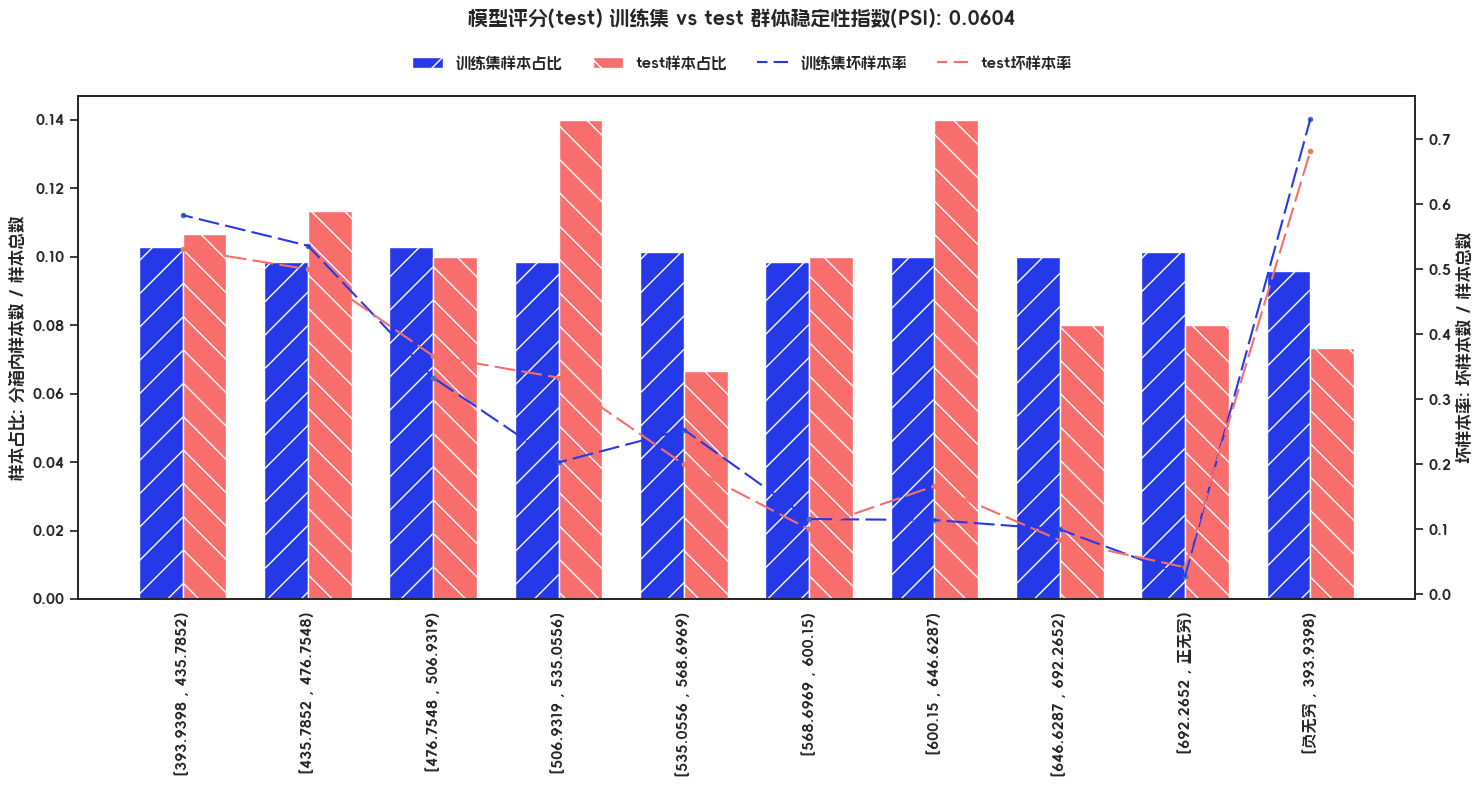

In [20]:
# 生成完整报告（包含图表）
report.to_excel(
    filepath='model_report/credit_scorecard_report.xlsx',
    n_bins=10,
    bin_method='quantile',
    with_plots=True,
    model_name='CreditScoreCard',
    project_desc='德国信贷评分卡模型（详细版）',
    feature_map=feature_map,
    data_source='German Credit Dataset',
)

In [21]:
# 查看生成的报告文件
for f in ['model_report/model_report.xlsx', 'model_report/credit_scorecard_report.xlsx']:
    if os.path.exists(f):
        print(f"{f}: {os.path.getsize(f) / 1024:.2f} KB")

# 查看图表目录
if os.path.exists('credit_scorecard_report_assets'):
    print("\n生成的图表文件:")
    for f in os.listdir('credit_scorecard_report_assets'):
        print(f"  - {f}")

model_report/model_report.xlsx: 7373.84 KB
model_report/credit_scorecard_report.xlsx: 4255.34 KB

生成的图表文件:
  - bin_age_in_years_test.png
  - bin_age_in_years_train.png
  - bin_credit_amount_test.png
  - bin_credit_amount_train.png
  - bin_credit_history_test.png
  - bin_credit_history_train.png
  - bin_housing_test.png
  - bin_housing_train.png
  - bin_property_test.png
  - bin_property_train.png
  - bin_purpose_test.png
  - bin_purpose_train.png
  - bin_savings_account_and_bonds_test.png
  - bin_savings_account_and_bonds_train.png
  - bin_status_of_existing_checking_account_test.png
  - bin_status_of_existing_checking_account_train.png
  - bin_test.png
  - bin_train.png
  - ks_test.png
  - ks_train.png
  - score_psi_test.png


### 总结

本 notebook 演示了：

1. **Pipeline 构建评分卡**：使用 `FeatureSelection`、`Combiner`、`WOETransformer`、`StepwiseSelection`、`ITLubberLogisticRegression` 构建端到端评分卡建模流程

2. **评分卡模型训练**：使用 `ScoreCard` 构建评分卡模型，支持系数查看、刻度配置、分值表生成

3. **自动报告生成**：使用 `auto_model_report` 或 `QuickModelReport` 一键生成多 Sheet 结构的 Excel 模型评估报告

报告包含以下内容：
- 目录（带超链接）
- 1-基本信息（项目目标、样本统计）
- 2-模型性能（KS/AUC/PSI、TOP n% LIFT、评分分箱）
- 3-入模变量分析（重要性、相关性、逐特征分箱）
- 4-稳定性分析（评分分布、PSI矩阵、漂移分析）
- 5-模型参数（评分卡分值表）
- 6-模型部署需求（入模变量信息、测试用例）